In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import warnings
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

try:
    from hypothesaes.quickstart import train_sae
    HAS_SAE_LIB = True
except ImportError:
    HAS_SAE_LIB = False
    print("WARNING: 'hypothesaes' library not found. SAE will not be available.")

TEST_SIZE = 0.1
RANDOM_SEED = 42

CACHE_FILE = 'pca_aggregate_survey_cache.pkl'

K_MODEL = 30
USE_PCA = True
PCA_COMPONENTS = 48
USE_SAE = True
SAE_FEATURES = 48
SAE_K_SPARSITY = 4
SAE_EPOCHS = 100
SAE_LR = 5e-4
SAE_BATCH_SIZE = 512

LAMBDA_TAU = 0.002
TAU_INIT = 0.5
TAU_WARMUP = 200
RAMP_EPOCHS = 200
SNAPPING_THRESHOLD = 0.005
DEAD_ZONE_VALUE = -0.1
TAU_THRESHOLD = 0.01

EPOCHS = 1000
EVAL_EVERY = 100
PATIENCE = 30
MIN_DELTA = 1e-6

LR_THETA = 0.02
LR_GLOBAL = 0.005
WD_THETA = 1e-3
WD_W = 1e-5

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
def load_cache():
    if os.path.exists(CACHE_FILE):
        print(f"Loading cache from {CACHE_FILE}...")
        with open(CACHE_FILE, 'rb') as f:
            return pickle.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)
    print(f"Cache saved to {CACHE_FILE}")

def compute_rmse(predictions, targets, mask):
    valid = mask.astype(bool) if isinstance(mask, np.ndarray) else mask
    return np.sqrt(mean_squared_error(targets[valid], predictions[valid]))

def trainer(parameters, optim, closure, n_iter=100, verbose=False):
    for iteration in range(n_iter):
        if iteration > 0:
            previous_parameters = [p.clone() for p in parameters]
            previous_loss = loss.clone()
        
        loss = optim.step(closure)
        
        if iteration > 0:
            d_loss = (previous_loss - loss).item()
            d_parameters = sum(
                torch.norm(prev - curr, p=2).item()
                for prev, curr in zip(previous_parameters, parameters)
            )
            grad_norm = sum(torch.norm(p.grad, p=2).item() for p in parameters if p.grad is not None)
            
            if d_loss < 1e-5 and d_parameters < 1e-5 and grad_norm < 1e-5:
                break
    return parameters

class ReluARDModel(nn.Module):
    def __init__(self, N, J, K, d, x_j_emb, dropout=0.0):
        super().__init__()
        self.register_buffer('x_j', x_j_emb)
        self.dropout = dropout
        self.theta = nn.Parameter(torch.randn(N, K) * 0.01)
        self.theta_bias = nn.Parameter(torch.zeros(N))
        self.global_bias = nn.Parameter(torch.zeros(1))
        self.W = nn.Parameter(torch.randn(K, d) * 0.01)
        self.tau_raw = nn.Parameter(torch.ones(K) * TAU_INIT)
        self.difficulty_proj = nn.Linear(d, 1)

    def get_tau(self):
        return F.relu(self.tau_raw)

    def forward(self):
        W_norm = F.normalize(self.W, dim=1)
        base_loadings = self.x_j @ W_norm.T
        tau = self.get_tau()
        a_j = base_loadings * tau.unsqueeze(0)
        if self.training and self.dropout > 0:
            a_j = F.dropout(a_j, p=self.dropout)
        diff = self.difficulty_proj(self.x_j).squeeze()
        logits = self.theta @ a_j.T + diff.unsqueeze(0) + self.theta_bias.unsqueeze(1) + self.global_bias
        return torch.sigmoid(logits)

resmat_dir = 'resmats'
all_files = sorted([f for f in os.listdir(resmat_dir) if f.startswith('resmat')])
total_files = len(all_files)

emb_file = 'result/all_benchmarks_embeddings_4096_8B.pkl'
raw_embs_map = {}
if os.path.exists(emb_file):
    print("Loading embeddings dictionary...")
    emb_df = pd.read_pickle(emb_file)
    for _, r in emb_df.iterrows():
        raw_embs_map[str(r['benchmark.task_id'])] = r['embedding']
        if str(r['benchmark.task_id']).startswith('colbench_backend_programming'):
            suffix = str(r['benchmark.task_id']).split('.')[-1]
            raw_embs_map[f'colbench.{suffix}'] = r['embedding']

Loading embeddings dictionary...


In [ ]:
from sklearn.metrics import roc_auc_score

print("="*60)
print("ESTABLISHING ORACLE GROUND TRUTH")
print("="*60)

all_dfs = []
for f in all_files:
    all_dfs.append(pd.read_csv(os.path.join(resmat_dir, f), index_col=0))

global_shared_indices = set(all_dfs[0].index)
for df in all_dfs[1:]:
    global_shared_indices = global_shared_indices.intersection(set(df.index))
global_shared_indices = sorted(list(global_shared_indices))

print(f"Total matrices: {len(all_dfs)}")
print(f"Global user intersection: {len(global_shared_indices)} users")

oracle_dfs_filtered = [df.loc[global_shared_indices] for df in all_dfs]
oracle_stacked = np.array([df.values for df in oracle_dfs_filtered])
oracle_matrix = np.nanmean(oracle_stacked, axis=0)
oracle_df = pd.DataFrame(oracle_matrix, index=global_shared_indices, columns=oracle_dfs_filtered[0].columns)

print(f"Oracle matrix shape: {oracle_df.shape}")
print(f"Oracle contains {np.isnan(oracle_matrix).sum()} NaN values")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

N_oracle, J_oracle = oracle_df.shape
J_indices_oracle = np.arange(J_oracle)
np.random.shuffle(J_indices_oracle)

n_test_oracle = int(TEST_SIZE * J_oracle)
test_idx_oracle = J_indices_oracle[:n_test_oracle]
train_idx_oracle = J_indices_oracle[n_test_oracle:]

print(f"Train items: {len(train_idx_oracle)}, Test items: {len(test_idx_oracle)}")

oracle_values = oracle_df.values.copy()
oracle_values_clean = np.nan_to_num(oracle_values, nan=0.5)
y_oracle = torch.from_numpy(oracle_values_clean.astype(np.float32)).to(device)

train_mask_oracle = np.zeros_like(oracle_df.values, dtype=bool)
train_mask_oracle[:, train_idx_oracle] = ~np.isnan(oracle_df.values)[:, train_idx_oracle]

test_mask_oracle = np.zeros_like(oracle_df.values, dtype=bool)
test_mask_oracle[:, test_idx_oracle] = ~np.isnan(oracle_df.values)[:, test_idx_oracle]

train_mask_oracle_t = torch.from_numpy(train_mask_oracle).to(device)
test_mask_oracle_t = torch.from_numpy(test_mask_oracle).to(device)

task_ids_oracle = oracle_df.columns.tolist()
oracle_raw_embs = []
for task_id in task_ids_oracle:
    emb = raw_embs_map.get(str(task_id))
    if emb is None and task_id.startswith('colbench.'):
        number = task_id.split('.')[-1]
        emb = raw_embs_map.get(f'colbench_backend_programming.{number}')
    
    if emb is None:
        emb = np.zeros(4096)
    elif isinstance(emb, str):
        emb = ast.literal_eval(emb)
    oracle_raw_embs.append(emb)

x_np_oracle = np.array(oracle_raw_embs)

if USE_PCA:
    pca_oracle = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)
    x_transformed_pca = pca_oracle.fit_transform(x_np_oracle)
    embedding_dim_pca = PCA_COMPONENTS
else:
    x_transformed_pca = x_np_oracle
    embedding_dim_pca = x_np_oracle.shape[1]

x_transformed_pca = x_transformed_pca / (np.linalg.norm(x_transformed_pca, axis=1, keepdims=True) + 1e-8)
x_j_pca = torch.tensor(x_transformed_pca, dtype=torch.float32).to(device)

print(f"PCA embeddings prepared: {x_j_pca.shape}")

if USE_SAE and HAS_SAE_LIB:
    print(f"Training SAE (M={SAE_FEATURES}, K={SAE_K_SPARSITY})...")
    x_np_normalized = x_np_oracle / (np.linalg.norm(x_np_oracle, axis=1, keepdims=True) + 1e-8)
    sae = train_sae(
        embeddings=x_np_normalized,
        M=SAE_FEATURES,
        K=SAE_K_SPARSITY,
        batch_size=SAE_BATCH_SIZE,
        n_epochs=SAE_EPOCHS,
        learning_rate=SAE_LR,
        checkpoint_dir='checkpoints/hal_sae_temp'
    )
    x_transformed_sae = sae.get_activations(x_np_normalized)
    embedding_dim_sae = SAE_FEATURES
    x_transformed_sae = x_transformed_sae / (np.linalg.norm(x_transformed_sae, axis=1, keepdims=True) + 1e-8)
    x_j_sae = torch.tensor(x_transformed_sae, dtype=torch.float32).to(device)
    print(f"SAE embeddings prepared: {x_j_sae.shape}")
else:
    x_j_sae = None
    embedding_dim_sae = None
    if USE_SAE:
        print("SAE requested but library not available, skipping SAE model")

cache = load_cache()
results = []

print("\n" + "="*60)
print(f"STARTING MAIN LOOP: n=1 to n={total_files}")
print("="*60)

for n_current_files in range(1, total_files + 1):
    if n_current_files in cache:
        print(f"\n[{n_current_files}/{total_files}] Loading from cache...")
        results.append(cache[n_current_files])
        continue
    
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    
    print(f"\n[{n_current_files}/{total_files}] Processing with {n_current_files} sample(s)...")
    
    current_dfs = [all_dfs[i].loc[global_shared_indices] for i in range(n_current_files)]
    current_stacked = np.array([df.values for df in current_dfs])
    
    train_target_matrix = np.nanmean(current_stacked, axis=0)
    train_target_df = pd.DataFrame(train_target_matrix, index=global_shared_indices, columns=current_dfs[0].columns)
    
    train_values = np.nan_to_num(train_target_df.values, nan=0.5)
    y_train = torch.from_numpy(train_values.astype(np.float32)).to(device)
    
    train_mask_current = np.zeros_like(train_target_df.values, dtype=bool)
    train_mask_current[:, train_idx_oracle] = ~np.isnan(train_target_df.values)[:, train_idx_oracle]
    train_mask_current_t = torch.from_numpy(train_mask_current).to(device)
    
    mean_val = y_train[train_mask_current_t].mean()
    pred_mean = mean_val.expand_as(y_oracle)
    rmse_mean = compute_rmse(pred_mean.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
    
    theta_rasch = nn.Parameter(torch.randn(N_oracle, device=device) * 0.1)
    beta_rasch = nn.Parameter(torch.randn(J_oracle, device=device) * 0.1)
    
    opt_rasch = torch.optim.LBFGS([theta_rasch, beta_rasch], lr=0.1, max_iter=20, 
                                    history_size=10, line_search_fn="strong_wolfe")
    
    def closure_rasch():
        opt_rasch.zero_grad()
        probs = torch.sigmoid(theta_rasch.unsqueeze(1) - beta_rasch.unsqueeze(0))
        loss = F.binary_cross_entropy(probs, y_train, reduction='none')
        total_loss = (loss * train_mask_current_t).sum() / train_mask_current_t.sum()
        total_loss.backward()
        return total_loss
    
    for _ in range(100):
        opt_rasch.step(closure_rasch)
    
    with torch.no_grad():
        p_rasch = torch.sigmoid(theta_rasch.unsqueeze(1) - beta_rasch.unsqueeze(0))
        rmse_rasch = compute_rmse(p_rasch.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
    
    model_pca = ReluARDModel(N_oracle, J_oracle, K_MODEL, embedding_dim_pca, x_j_pca, dropout=0.5).to(device)
    optimizer_pca = optim.AdamW([
        {'params': [model_pca.theta, model_pca.theta_bias], 'lr': LR_THETA, 'weight_decay': WD_THETA},
        {'params': [model_pca.W, model_pca.tau_raw, model_pca.global_bias], 'lr': LR_GLOBAL, 'weight_decay': WD_W},
        {'params': model_pca.difficulty_proj.parameters(), 'lr': LR_GLOBAL}
    ])
    
    best_pca_rmse = float('inf')
    
    for epoch in range(EPOCHS + 1):
        model_pca.train()
        optimizer_pca.zero_grad()
        probs = model_pca()
        
        loss_fit = F.binary_cross_entropy(probs[train_mask_current_t], y_train[train_mask_current_t])
        
        if epoch < TAU_WARMUP:
            current_lambda = 0.0
        elif epoch < TAU_WARMUP + RAMP_EPOCHS:
            progress = (epoch - TAU_WARMUP) / RAMP_EPOCHS
            current_lambda = LAMBDA_TAU * progress
        else:
            current_lambda = LAMBDA_TAU
        
        tau = model_pca.get_tau()
        loss_sparsity = current_lambda * torch.sum(tau)
        (loss_fit + loss_sparsity).backward()
        optimizer_pca.step()
        
        if epoch > TAU_WARMUP + 50 and epoch % 10 == 0:
            with torch.no_grad():
                active_mask = model_pca.get_tau() > SNAPPING_THRESHOLD
                for k in range(K_MODEL):
                    if not active_mask[k]:
                        model_pca.tau_raw[k] = DEAD_ZONE_VALUE
        
        if epoch % EVAL_EVERY == 0:
            model_pca.eval()
            with torch.no_grad():
                p_pca = model_pca()
                curr_rmse = compute_rmse(p_pca.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
                best_pca_rmse = min(best_pca_rmse, curr_rmse)
    
    if x_j_sae is not None:
        model_sae = ReluARDModel(N_oracle, J_oracle, K_MODEL, embedding_dim_sae, x_j_sae, dropout=0.5).to(device)
        optimizer_sae = optim.AdamW([
            {'params': [model_sae.theta, model_sae.theta_bias], 'lr': LR_THETA, 'weight_decay': WD_THETA},
            {'params': [model_sae.W, model_sae.tau_raw, model_sae.global_bias], 'lr': LR_GLOBAL, 'weight_decay': WD_W},
            {'params': model_sae.difficulty_proj.parameters(), 'lr': LR_GLOBAL}
        ])
        
        best_sae_rmse = float('inf')
        
        for epoch in range(EPOCHS + 1):
            model_sae.train()
            optimizer_sae.zero_grad()
            probs = model_sae()
            
            loss_fit = F.binary_cross_entropy(probs[train_mask_current_t], y_train[train_mask_current_t])
            
            if epoch < TAU_WARMUP:
                current_lambda = 0.0
            elif epoch < TAU_WARMUP + RAMP_EPOCHS:
                progress = (epoch - TAU_WARMUP) / RAMP_EPOCHS
                current_lambda = LAMBDA_TAU * progress
            else:
                current_lambda = LAMBDA_TAU
            
            tau = model_sae.get_tau()
            loss_sparsity = current_lambda * torch.sum(tau)
            (loss_fit + loss_sparsity).backward()
            optimizer_sae.step()
            
            if epoch > TAU_WARMUP + 50 and epoch % 10 == 0:
                with torch.no_grad():
                    active_mask = model_sae.get_tau() > SNAPPING_THRESHOLD
                    for k in range(K_MODEL):
                        if not active_mask[k]:
                            model_sae.tau_raw[k] = DEAD_ZONE_VALUE
            
            if epoch % EVAL_EVERY == 0:
                model_sae.eval()
                with torch.no_grad():
                    p_sae = model_sae()
                    curr_rmse = compute_rmse(p_sae.cpu().numpy(), y_oracle.cpu().numpy(), test_mask_oracle)
                    best_sae_rmse = min(best_sae_rmse, curr_rmse)
    else:
        best_sae_rmse = float('inf')
    
    def evaluate_auc(y_pred_tensor, y_true_oracle_tensor, mask_tensor):
        y_true_flat = y_true_oracle_tensor[mask_tensor].detach().cpu().numpy()
        y_pred_flat = y_pred_tensor[mask_tensor].detach().cpu().numpy()
        y_true_binary = (y_true_flat > 0.5).astype(int)
        if len(np.unique(y_true_binary)) < 2:
            return 0.5
        try:
            return roc_auc_score(y_true_binary, y_pred_flat)
        except ValueError:
            return 0.5
    
    auc_mean = evaluate_auc(pred_mean, y_oracle, test_mask_oracle_t)
    auc_rasch = evaluate_auc(p_rasch, y_oracle, test_mask_oracle_t)
    
    model_pca.eval()
    with torch.no_grad():
        p_pca_final = model_pca()
        auc_pca = evaluate_auc(p_pca_final, y_oracle, test_mask_oracle_t)
    
    if x_j_sae is not None:
        model_sae.eval()
        with torch.no_grad():
            p_sae_final = model_sae()
            auc_sae = evaluate_auc(p_sae_final, y_oracle, test_mask_oracle_t)
    else:
        auc_sae = 0.5
    
    print(f"   -> RMSE | Mean: {rmse_mean:.4f} | Rasch: {rmse_rasch:.4f} | PCA-IRT: {best_pca_rmse:.4f} | SAE-IRT: {best_sae_rmse:.4f}")
    print(f"   -> AUC  | Mean: {auc_mean:.4f} | Rasch: {auc_rasch:.4f} | Amortised: {auc_pca:.4f} | SAE-IRT: {auc_sae:.4f}")
    
    result_entry = {
        'n_samples': n_current_files,
        'rmse_mean': rmse_mean,
        'rmse_rasch': rmse_rasch,
        'rmse_pca': best_pca_rmse,
        'rmse_sae': best_sae_rmse,
        'auc_mean': auc_mean,
        'auc_rasch': auc_rasch,
        'auc_pca': auc_pca,
        'auc_sae': auc_sae
    }
    
    results.append(result_entry)
    cache[n_current_files] = result_entry
    save_cache(cache)

print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)

ESTABLISHING ORACLE GROUND TRUTH


Total matrices: 22
Global user intersection: 8 users
Oracle matrix shape: (8, 1000)
Oracle contains 0 NaN values
Train items: 900, Test items: 100
PCA embeddings prepared: torch.Size([1000, 48])
Training SAE (M=48, K=4)...
Loaded model from checkpoints/hal_sae_temp/SAE_M=48_K=4.pt onto device cuda


Computing activations (batchsize=16384):   0%|          | 0/1 [00:00<?, ?it/s]

SAE embeddings prepared: torch.Size([1000, 48])

STARTING MAIN LOOP: n=1 to n=22

[1/22] Processing with 1 sample(s)...
   -> RMSE | Mean: 0.2076 | Rasch: 0.3071 | PCA-IRT: 0.1939 | SAE-IRT: 0.1968
   -> AUC  | Mean: 0.5000 | Rasch: 0.6143 | PCA-IRT: 0.7280 | SAE-IRT: 0.7077
Cache saved to pca_aggregate_survey_cache.pkl

[2/22] Processing with 2 sample(s)...
   -> RMSE | Mean: 0.2054 | Rasch: 0.2370 | PCA-IRT: 0.1882 | SAE-IRT: 0.1917
   -> AUC  | Mean: 0.5000 | Rasch: 0.5953 | PCA-IRT: 0.7244 | SAE-IRT: 0.7106
Cache saved to pca_aggregate_survey_cache.pkl

[3/22] Processing with 3 sample(s)...
   -> RMSE | Mean: 0.2041 | Rasch: 0.2358 | PCA-IRT: 0.1757 | SAE-IRT: 0.1846
   -> AUC  | Mean: 0.5000 | Rasch: 0.5822 | PCA-IRT: 0.8114 | SAE-IRT: 0.7553
Cache saved to pca_aggregate_survey_cache.pkl

[4/22] Processing with 4 sample(s)...
   -> RMSE | Mean: 0.2037 | Rasch: 0.2383 | PCA-IRT: 0.1748 | SAE-IRT: 0.1847
   -> AUC  | Mean: 0.5000 | Rasch: 0.5723 | PCA-IRT: 0.8185 | SAE-IRT: 0.7592
C

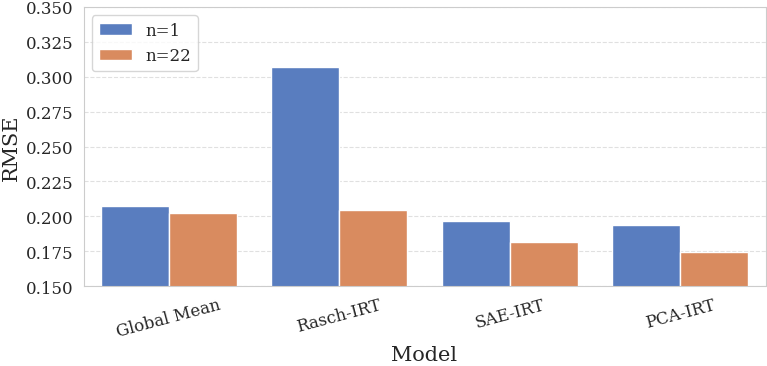

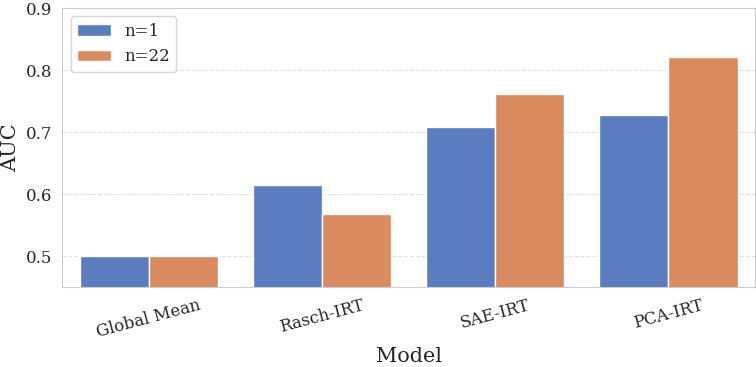

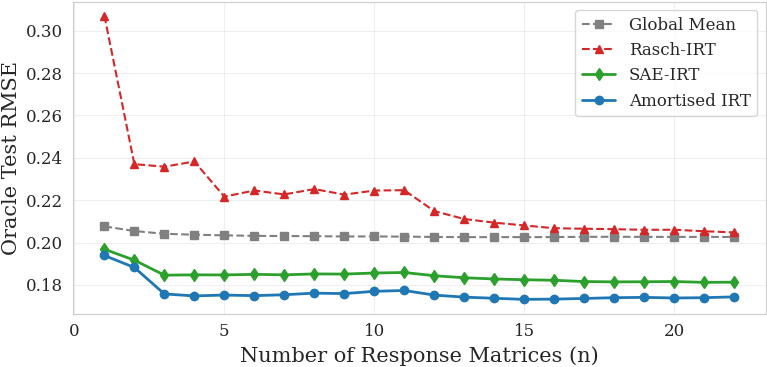

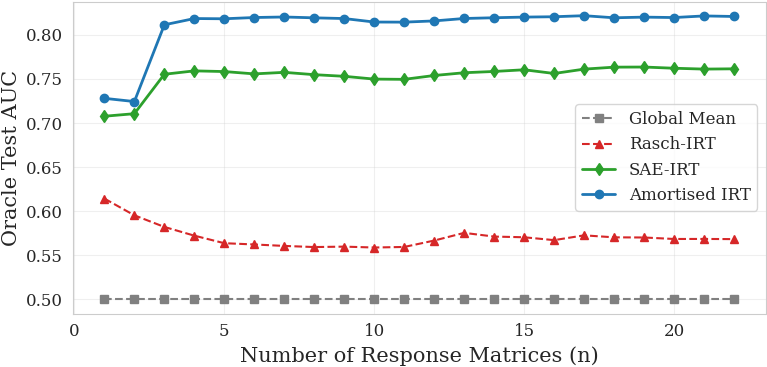

Visualizations saved:
  - plots/rmse_comparison.pdf
  - plots/auc_comparison.pdf
  - plots/rmse_convergence.pdf
  - plots/auc_convergence.pdf


In [22]:
import sys
sys.path.append('..') 
import style

df_full = pd.DataFrame(results)
n_max = df_full['n_samples'].max()

df_comp = df_full[df_full['n_samples'].isin([1, n_max])].copy()
df_comp['n_label'] = df_comp['n_samples'].apply(lambda x: f"n={x}")

rmse_melt = df_comp.melt(id_vars=['n_label'], value_vars=['rmse_mean', 'rmse_rasch', 'rmse_sae', 'rmse_pca'], 
						var_name='Model', value_name='RMSE')
auc_melt = df_comp.melt(id_vars=['n_label'], value_vars=['auc_mean', 'auc_rasch', 'auc_sae', 'auc_pca'], 
					   var_name='Model', value_name='AUC')

model_map = {
	'rmse_mean': 'Global Mean', 'rmse_rasch': 'Rasch-IRT', 'rmse_sae': 'SAE-IRT', 'rmse_pca': 'PCA-IRT',
	'auc_mean': 'Global Mean', 'auc_rasch': 'Rasch-IRT', 'auc_sae': 'SAE-IRT', 'auc_pca': 'PCA-IRT'
}
rmse_melt['Model'] = rmse_melt['Model'].map(model_map)
auc_melt['Model'] = auc_melt['Model'].map(model_map)

model_order = ['Global Mean', 'Rasch-IRT', 'SAE-IRT', 'PCA-IRT']

# Plot 1: RMSE Comparison
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=rmse_melt, x='Model', y='RMSE', hue='n_label', order=model_order, ax=ax, palette="muted")
ax.set_ylim(0.15, 0.35)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plots/rmse_comparison.pdf', bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: AUC Comparison
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=auc_melt, x='Model', y='AUC', hue='n_label', order=model_order, ax=ax, palette="muted")
ax.set_ylim(0.45, 0.9)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plots/auc_comparison.pdf', bbox_inches='tight')
plt.show()
plt.close()

# Plot 3: RMSE Convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_full['n_samples'], df_full['rmse_mean'], 's--', label='Global Mean', color='gray')
ax.plot(df_full['n_samples'], df_full['rmse_rasch'], '^--', label='Rasch-IRT', color='tab:red')
ax.plot(df_full['n_samples'], df_full['rmse_sae'], 'd-', label='SAE-IRT', color='tab:green', linewidth=2)
ax.plot(df_full['n_samples'], df_full['rmse_pca'], 'o-', label='Amortised IRT', color='tab:blue', linewidth=2)
ax.set_xlabel('Number of Response Matrices (n)')
ax.set_ylabel('Oracle Test RMSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/rmse_convergence.pdf', bbox_inches='tight')
plt.show()
plt.close()

# Plot 4: AUC Convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_full['n_samples'], df_full['auc_mean'], 's--', label='Global Mean', color='gray')
ax.plot(df_full['n_samples'], df_full['auc_rasch'], '^--', label='Rasch-IRT', color='tab:red')
ax.plot(df_full['n_samples'], df_full['auc_sae'], 'd-', label='SAE-IRT', color='tab:green', linewidth=2)
ax.plot(df_full['n_samples'], df_full['auc_pca'], 'o-', label='Amortised IRT', color='tab:blue', linewidth=2)
ax.set_xlabel('Number of Response Matrices (n)')
ax.set_ylabel('Oracle Test AUC')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/auc_convergence.pdf', bbox_inches='tight')
plt.show()
plt.close()

print("Visualizations saved:")
print("  - plots/rmse_comparison.pdf")
print("  - plots/auc_comparison.pdf")
print("  - plots/rmse_convergence.pdf")
print("  - plots/auc_convergence.pdf")
